# Advanced Task 2 — Customer Segmentation (Unsupervised Learning)

## Objective
Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

## Requirements Covered
- Exploratory Data Analysis (EDA)
- K-Means clustering
- PCA (or t-SNE) to visualize clusters
- Marketing strategy suggestions for each cluster

## Dataset
Mall Customers Dataset (commonly `Mall_Customers.csv`)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# -----------------------
# Paths (auto root)
# -----------------------
def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "data").exists():
            return p
    return start

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs" / "adv_task2"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT   :", ROOT)
print("DATA   :", DATA_DIR)
print("OUTPUT :", OUT_DIR)

def save_fig(name: str) -> None:
    try:
        path = OUT_DIR / name
        plt.tight_layout()
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print("Saved:", path)
    except Exception as e:
        print("Note: could not save figure:", e)

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip().str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return df

def find_mall_csv(data_dir: Path) -> Path | None:
    csvs = sorted(data_dir.glob("*.csv"))
    # prefer Mall_Customers.csv
    for f in csvs:
        if f.name.lower() == "mall_customers.csv":
            return f
    # fallback: any file containing 'mall' or 'customer'
    for f in csvs:
        n = f.name.lower()
        if "mall" in n or ("customer" in n and "seg" in n):
            return f
    # if only one csv exists, use it
    if len(csvs) == 1:
        return csvs[0]
    return None

ROOT   : f:\coding\DevelopersHub-Advanced-Tasks
DATA   : f:\coding\DevelopersHub-Advanced-Tasks\data
OUTPUT : f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2


In [2]:
DATA_PATH = find_mall_csv(DATA_DIR)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"No mall customer CSV found in {DATA_DIR}.\n"
        "Fix: put dataset CSV inside data/ (e.g., Mall_Customers.csv)."
    )

df_raw = pd.read_csv(DATA_PATH)
df = normalize_columns(df_raw)

print("Using dataset:", DATA_PATH.name)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

# Basic checks
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_pct[missing_pct > 0].to_frame("missing_%"))
print("Duplicate rows:", int(df.duplicated().sum()))

Using dataset: Mall_Customers.csv
Shape: (200, 5)
Columns: ['customerid', 'gender', 'age', 'annual_income_k', 'spending_score_1_100']


,customerid,gender,age,annual_income_k,spending_score_1_100
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,missing_%


Duplicate rows: 0


## EDA (Exploratory Data Analysis)

We will:
- Review distributions of numeric columns
- Visualize relationship between income and spending score (if available)
- Check gender distribution (if available)

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\eda_numeric_histograms.png


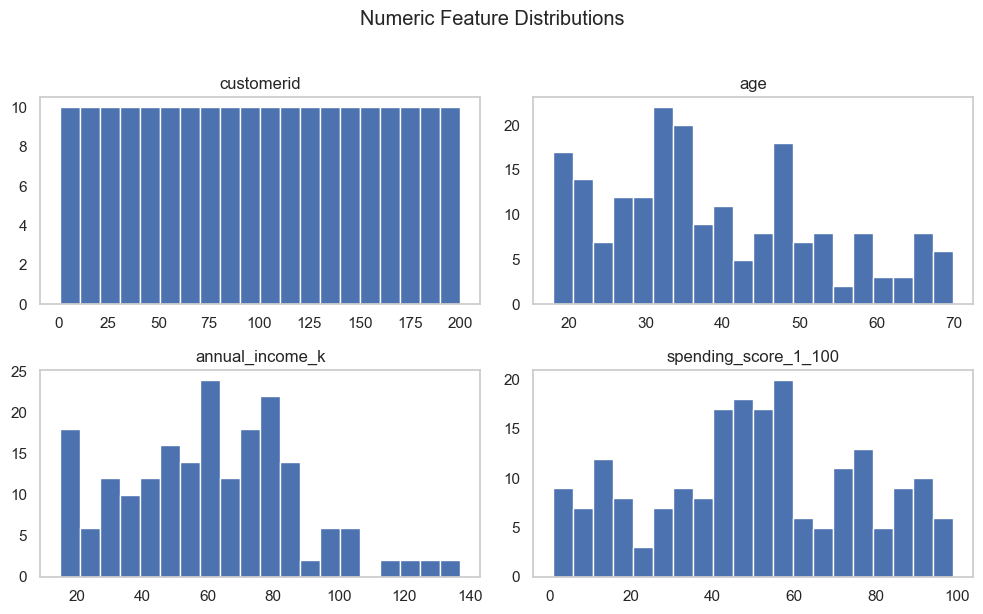

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\eda_gender_distribution.png


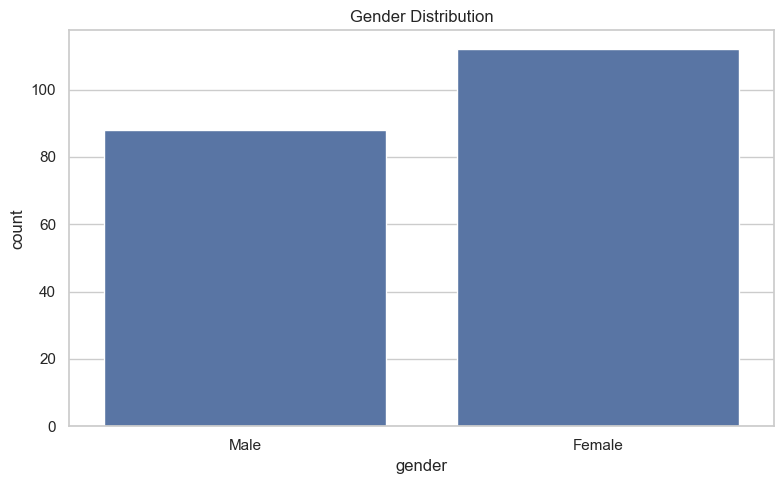

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\eda_income_vs_spending.png


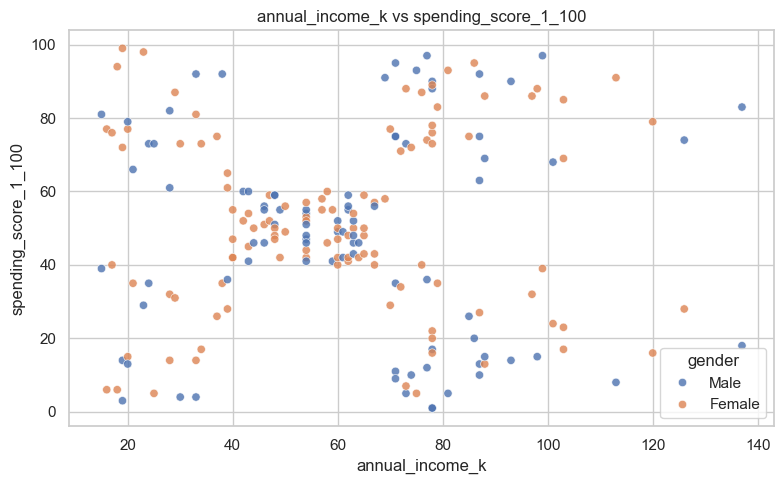

In [3]:
# Numeric distributions
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols_all:
    df[num_cols_all].hist(bins=20, figsize=(10, 6), grid=False)
    plt.suptitle("Numeric Feature Distributions", y=1.02)
    save_fig("eda_numeric_histograms.png")
    plt.show()

# Gender distribution (if exists)
if "gender" in df.columns:
    sns.countplot(data=df, x="gender")
    plt.title("Gender Distribution")
    save_fig("eda_gender_distribution.png")
    plt.show()

# Income vs spending (if we can detect columns)
income_col = next((c for c in df.columns if "income" in c), None)
spend_col = next((c for c in df.columns if ("spending" in c and "score" in c) or c.endswith("spending_score")), None)

if income_col and spend_col:
    sns.scatterplot(data=df, x=income_col, y=spend_col, hue="gender" if "gender" in df.columns else None, alpha=0.8)
    plt.title(f"{income_col} vs {spend_col}")
    save_fig("eda_income_vs_spending.png")
    plt.show()
else:
    print("Income/Spending columns not detected for scatter plot. Detected income:", income_col, "spending:", spend_col)

## Feature Selection + Scaling

K-Means works best when features are scaled.
We will prefer typical segmentation features:
- Annual income
- Spending score
(Optional) Age

If these columns are not found, we will use all numeric columns except ID-like fields.

In [4]:
# Identify common columns
age_col = "age" if "age" in df.columns else None
income_col = next((c for c in df.columns if "income" in c), income_col)
spend_col = next((c for c in df.columns if ("spending" in c and "score" in c)), spend_col)

# Build feature list with preference
preferred = [c for c in [age_col, income_col, spend_col] if c is not None]

# Fallback: all numeric columns except ID-like columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
id_like = [c for c in numeric_cols if "id" in c or "customer" in c]
fallback = [c for c in numeric_cols if c not in id_like]

feature_cols = preferred if len(preferred) >= 2 else fallback

if len(feature_cols) < 2:
    raise ValueError(f"Not enough numeric features for clustering. Found: {feature_cols}")

X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Clustering features:", feature_cols)
print("X_scaled shape:", X_scaled.shape)

Clustering features: ['age', 'annual_income_k', 'spending_score_1_100']
X_scaled shape: (200, 3)


## Choosing the Number of Clusters (k)

We will use:
- Elbow method (inertia)
- Silhouette score

Then we will select a reasonable k (usually 3–6).

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\k_selection_elbow.png


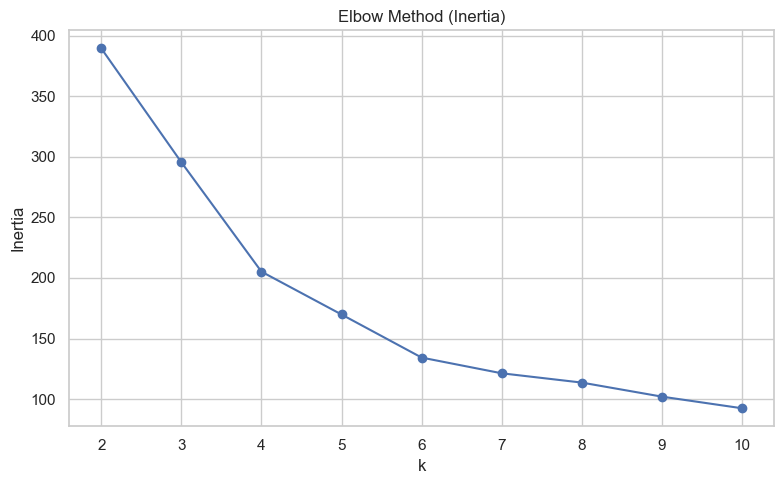

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\k_selection_silhouette.png


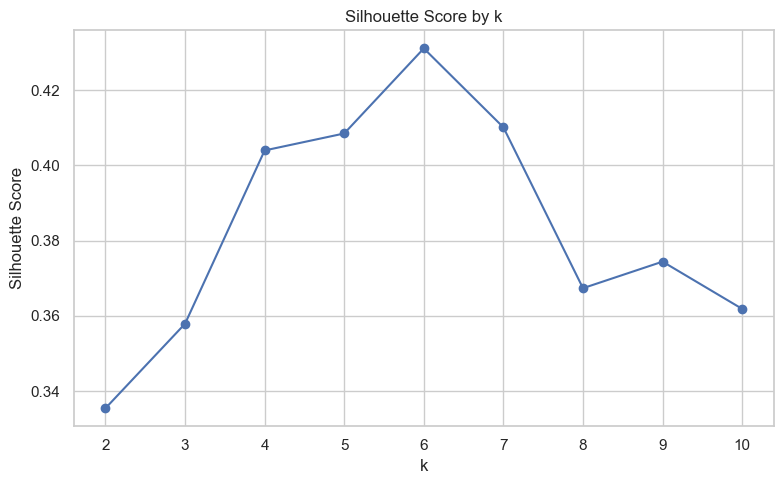

Suggested k (max silhouette): 6


In [5]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    # n_init compatibility (older sklearn doesn't support "auto")
    try:
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    except TypeError:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
save_fig("k_selection_elbow.png")
plt.show()

plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
save_fig("k_selection_silhouette.png")
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Suggested k (max silhouette):", best_k)

In [6]:
FINAL_K = best_k  # you can manually set e.g., 5

try:
    kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init="auto")
except TypeError:
    kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
display(df["cluster"].value_counts().sort_index())

Cluster counts:


cluster
0    45
1    39
2    25
3    40
4    30
5    21
Name: count, dtype: int64

## Visualize Clusters with PCA

We reduce the (scaled) feature space into 2D using PCA and plot clusters.

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\clusters_pca.png


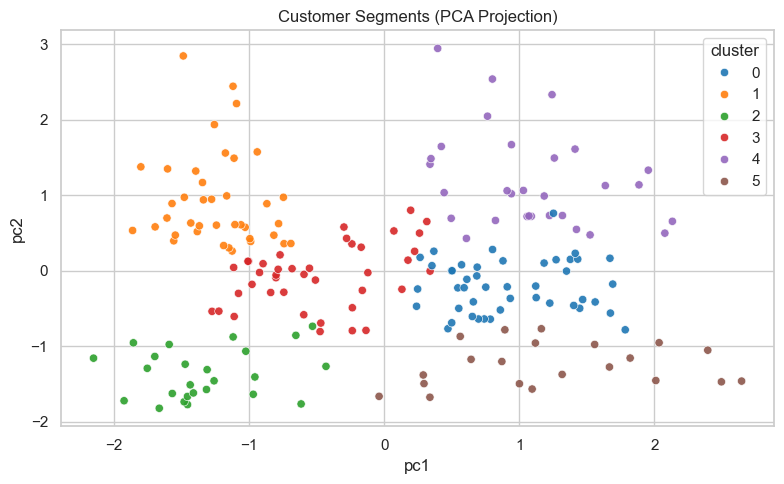

Explained variance (PC1, PC2): [0.4427 0.3331]


In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["pc1", "pc2"])
pca_df["cluster"] = df["cluster"].values

sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="cluster", palette="tab10", alpha=0.9)
plt.title("Customer Segments (PCA Projection)")
save_fig("clusters_pca.png")
plt.show()

print("Explained variance (PC1, PC2):", np.round(pca.explained_variance_ratio_, 4))

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\clusters_tsne.png


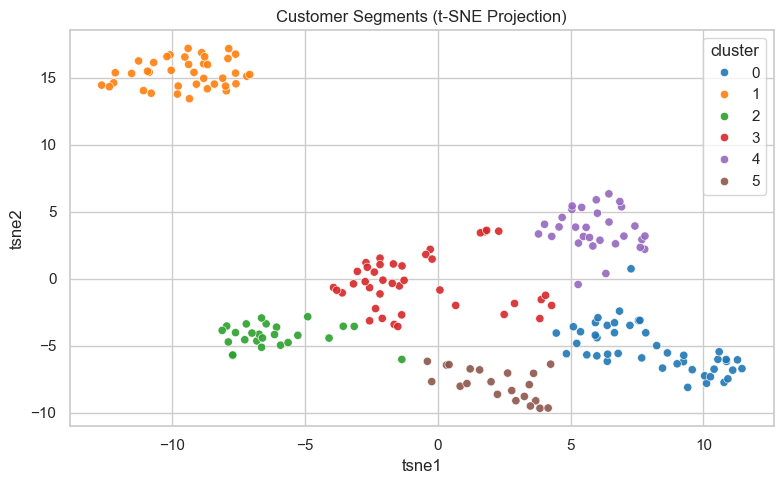

In [8]:
# Optional: t-SNE can be slow on large datasets.
# If you want, run this cell.
try:
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
    X_tsne = tsne.fit_transform(X_scaled)

    tsne_df = pd.DataFrame(X_tsne, columns=["tsne1", "tsne2"])
    tsne_df["cluster"] = df["cluster"].values

    sns.scatterplot(data=tsne_df, x="tsne1", y="tsne2", hue="cluster", palette="tab10", alpha=0.9)
    plt.title("Customer Segments (t-SNE Projection)")
    save_fig("clusters_tsne.png")
    plt.show()
except Exception as e:
    print("t-SNE skipped. Reason:", e)

## Cluster Profiling

We will compute average values per cluster and interpret segments.
This will be used to propose marketing strategies.

Cluster sizes:


,n
cluster,
0,45
1,39
2,25
3,40
4,30
5,21


Cluster means:


,age,annual_income_k,spending_score_1_100
cluster,,,
0,56.33,54.27,49.07
1,32.69,86.54,82.13
2,25.56,26.48,76.24
3,26.12,59.42,44.45
4,44.00,90.13,17.93
5,45.52,26.29,19.38


Cluster medians:


,age,annual_income_k,spending_score_1_100
cluster,,,
0,54.0,54.0,49.0
1,32.0,79.0,83.0
2,24.0,25.0,76.0
3,25.0,60.0,48.0
4,43.5,87.0,16.5
5,46.0,25.0,15.0


Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\profile_box_age.png


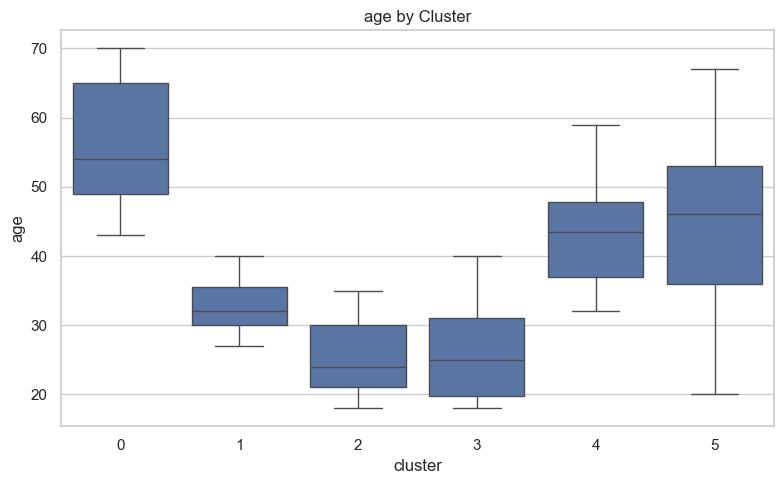

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\profile_box_annual_income_k.png


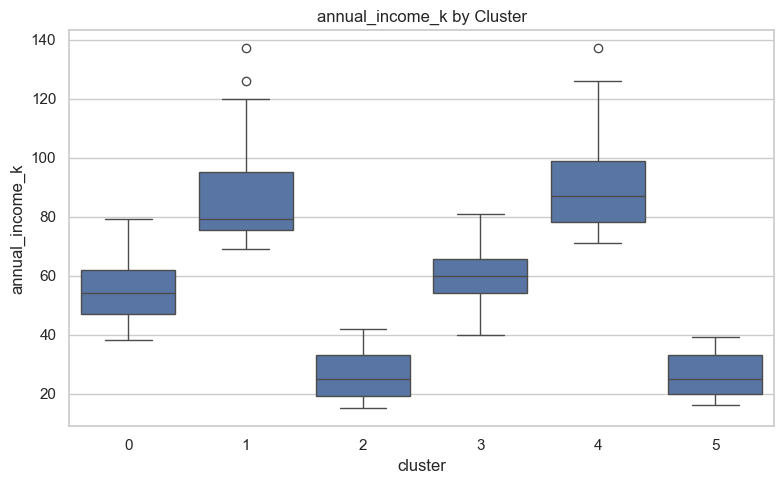

Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task2\profile_box_spending_score_1_100.png


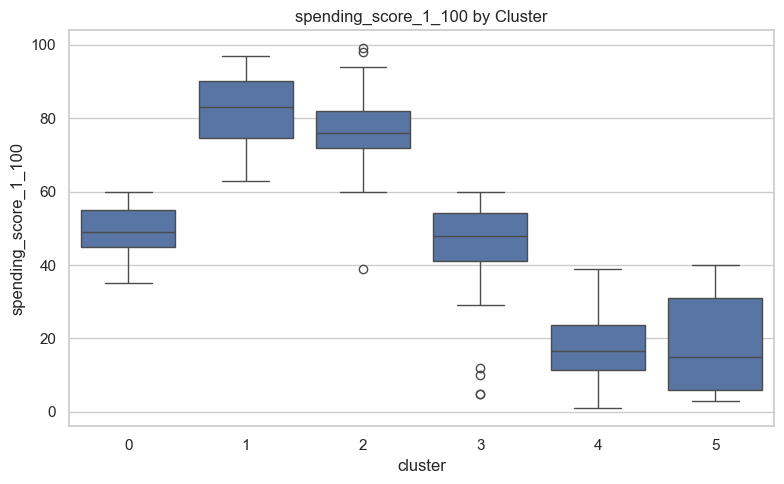

In [9]:
profile_mean = df.groupby("cluster")[feature_cols].mean().round(2)
profile_median = df.groupby("cluster")[feature_cols].median().round(2)
sizes = df["cluster"].value_counts().sort_index()

print("Cluster sizes:")
display(sizes.to_frame("n"))

print("Cluster means:")
display(profile_mean)

print("Cluster medians:")
display(profile_median)

# Visual: feature distribution by cluster (boxplots)
for col in feature_cols:
    sns.boxplot(data=df, x="cluster", y=col)
    plt.title(f"{col} by Cluster")
    save_fig(f"profile_box_{col}.png")
    plt.show()

## Marketing Strategy Suggestions (based on segments)

We will label each cluster using Income/Spending levels:
- low / mid / high (based on dataset percentiles)

Then we propose 2–3 actions per segment.

In [10]:
# Build a strategy table if income & spending exist, else use generic profiling
income_col = next((c for c in feature_cols if "income" in c), None)
spend_col = next((c for c in feature_cols if "spending" in c and "score" in c), None)

strategy_rows = []

def level(value, q33, q66):
    if value <= q33: return "low"
    if value <= q66: return "mid"
    return "high"

if income_col and spend_col:
    q_income_33, q_income_66 = df[income_col].quantile([0.33, 0.66]).values
    q_spend_33, q_spend_66 = df[spend_col].quantile([0.33, 0.66]).values

    for c in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == c]
        inc_mean = sub[income_col].mean()
        sp_mean = sub[spend_col].mean()

        inc_lvl = level(inc_mean, q_income_33, q_income_66)
        sp_lvl  = level(sp_mean, q_spend_33, q_spend_66)

        # Simple strategy rules
        if inc_lvl == "high" and sp_lvl == "high":
            strategy = "Premium offers, VIP loyalty program, exclusive launches."
        elif inc_lvl == "high" and sp_lvl in ["low", "mid"]:
            strategy = "Personalized recommendations, awareness campaigns, premium trial offers."
        elif inc_lvl in ["low", "mid"] and sp_lvl == "high":
            strategy = "Discount bundles, seasonal deals, reward points to keep engagement."
        else:
            strategy = "Mass promotions, price-sensitive offers, basic loyalty points."

        strategy_rows.append({
            "cluster": c,
            "income_level": inc_lvl,
            "spending_level": sp_lvl,
            "n_customers": len(sub),
            "suggested_strategy": strategy
        })

    strategy_df = pd.DataFrame(strategy_rows).sort_values(["income_level", "spending_level"])
    display(strategy_df)
else:
    print("Income/Spending columns not detected. Write strategies based on the cluster mean table above.")

,cluster,income_level,spending_level,n_customers,suggested_strategy
1,1,high,high,39,"Premium offers, VIP loyalty program, exclusive..."
4,4,high,low,30,"Personalized recommendations, awareness campai..."
2,2,low,high,25,"Discount bundles, seasonal deals, reward point..."
5,5,low,low,21,"Mass promotions, price-sensitive offers, basic..."
0,0,mid,mid,45,"Mass promotions, price-sensitive offers, basic..."
3,3,mid,mid,40,"Mass promotions, price-sensitive offers, basic..."


## Conclusion
- We segmented customers into **k = __** clusters using K-Means.
- PCA/t-SNE visualization shows clusters are (well separated / partially overlapping).
- Based on cluster profiles, we proposed marketing strategies for each segment.
- Next improvements: try different features, tune k, or compare with DBSCAN/GMM.